In [20]:
import numpy as np
import sys

sys.path.append('..')  # add project root

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import Datasets.load_mat_as_flat as lmf

from prog import mlps, featlib, trainer, hlprs
import Datasets.matconv as mc

import importlib
importlib.reload(mlps)
importlib.reload(trainer)
importlib.reload(hlprs)
importlib.reload(lmf)

<module 'Datasets.load_mat_as_flat' from 'c:\\Users\\Ethan\\Desktop\\Research\\pde_stuff\\ethan_work\\..\\Datasets\\load_mat_as_flat.py'>

In [21]:
# learning these
lam_tv = 1e-9
lam_pde = 1.0

lr_tv = 1e-4
lr_pde = 1e-3

#not learning these
lam_reg = 0.0
lam_data = 10.0

# hyperparameters for data generation
path = "../Datasets/data/raw/burgers.mat"
noise=0.5
nu=0.02
stride_t=1
stride_x=1
part_num=1
which_part=1
seed=1432

selected_derivs = ('u','u_x','u_xx')

correct_coeffs = [0.0, 0.0, nu, -1.0]  # corresponds to the correct PDE: u_t + u*u_x - nu*u_xx = 0


lr = 1e-3
batch_size = 1000
steps = 8000
log_every = 500

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


# building noisy dataset
partitions = lmf.load_burgers_mat_as_flat(mat_path=path,
                                          noise_level=noise, 
                                          stride_t=stride_t, 
                                          stride_x=stride_x, 
                                          seed=seed, 
                                          quantile_splits=part_num, 
                                          return_partitions=True)

key = [k for k in partitions if k.startswith(f'Q{which_part}:')][0]
t_np, x_np, y_np, y_noisy_np, N = partitions[key]

# torch tensors

t_torch       = torch.from_numpy(t_np).to(device)
x_torch       = torch.from_numpy(x_np).to(device)
y_clean_torch = torch.from_numpy(y_np).to(device)
y_noisy_torch = torch.from_numpy(y_noisy_np).to(device)

print('N points:', t_np.shape[0])
print("other points:", type(x_np.shape[0]))
print('x_unique:', len(np.unique(x_np)), 't_unique:', len(np.unique(t_np)))

Using device: cuda
N points: 25856
other points: <class 'int'>
x_unique: 256 t_unique: 101


c:\Users\Ethan\Desktop\Research\pde_stuff\ethan_work\..\Datasets\load_mat_as_flat.py:30: ComplexWarning: Casting complex values to real discards the imaginary part
  u = np.asarray(u, dtype=np.float64)


We'd like to be able to loop through different model iterations, with each iteration using a different masking function

In [22]:
def tv_mask_1(lam):
    return 1e-8 + 1e-4 * (1 / (1 + torch.exp(-(lam-1))))
def pde_mask_1(lam):
    return 40 * (1 / (1 + torch.exp(-(lam-1))))

def tv_mask_2(lam):
    return 1e-8 + 1e-4 * (1 / (1 + torch.exp(-(lam-1))))
def pde_mask_2(lam):
    return lam

def tv_mask_3(lam):
    return lam
def pde_mask_3(lam):
    return 40 * (1 / (1 + torch.exp(-(lam-1))))

def tv_mask_4(lam):
    return lam
def pde_mask_4(lam):
    return lam

tv_masks = [tv_mask_1, tv_mask_2, tv_mask_3, tv_mask_4]
pde_masks = [pde_mask_1, pde_mask_2, pde_mask_3, pde_mask_4]

In [23]:
def tv1d_space(u_fn, t, x, eps=1e-6):
    # Returns E[ sqrt( (du/dx)^2 + eps^2 ) ]
    u = u_fn(t, x)
    ones = torch.ones_like(u)
    ux = torch.autograd.grad(
        u, x,
        grad_outputs=ones,
        create_graph=True,
        retain_graph=True,
    )[0]
    tv = torch.sqrt(ux**2 + eps**2)
    return tv.mean()

def make_models():
    u_model = mlps.SirenMLP(hidden_layers=4, hidden_size=64, first_omega_0=1.0, hidden_omega_0=1.0)
    symnet = mlps.EQL(in_dim=len(selected_derivs), prod_dim=2, bias=False)
    return u_model, symnet

def make_trainer(u_model, symnet, tv_mask_fn, pde_mask_fn):
    train_config = trainer.TrainerConfig(
        lr=lr,
        lr_tv=lr_tv,
        lr_pde=lr_pde,
        lambda_pde= lam_pde,
        lambda_reg=lam_reg,
        lambda_tv= lam_tv,
        lambda_data=lam_data,
        lambda_tv_mask_fn = tv_mask_fn,
        lambda_pde_mask_fn = pde_mask_fn,
        selected_derivs=selected_derivs,
        device=device,
    )

    ft = featlib.FeatureTensor(selected_derivs, normalize=False)
    feature_builder = ft.build

    return trainer.SAPINNScalarTrainer(
        u_model=u_model,
        v_model=symnet,
        cfg=train_config,
        feature_builder=feature_builder,
    )


 
 
 
* * * * * * * * * * * * * 
running models with test1 masking functions...
Starting training loop...
Initial lambda_tv: 9.999999717180685e-10, Initial lambda_pde: 1.0000
step 0:
step 500:
loss 0.1002
loss_tv_raw 0.0660  | loss_pde_raw 0.0005
loss_tv_masked" 2.773513551801443e-05  | loss_pde_masked 20.3821
lambda_tv 0.04195476695895195 | lambda_pde 1.0382
step 1000:
loss 0.0830
loss_tv_raw 0.0838  | loss_pde_raw 0.0001
loss_tv_masked" 2.871630022127647e-05  | loss_pde_masked 20.5034
lambda_tv 0.09041067212820053 | lambda_pde 1.0504
step 1500:
loss 0.0896
loss_tv_raw 0.0770  | loss_pde_raw 0.0001
loss_tv_masked" 2.9757433367194608e-05  | loss_pde_masked 20.6100
lambda_tv 0.14074639976024628 | lambda_pde 1.0610
step 2000:
loss 0.0832
loss_tv_raw 0.0783  | loss_pde_raw 0.0001
loss_tv_masked" 3.0830808100290596e-05  | loss_pde_masked 20.7297
lambda_tv 0.19158993661403656 | lambda_pde 1.0730
step 2500:
loss 0.0914
loss_tv_raw 0.0777  | loss_pde_raw 0.0001
loss_tv_masked" 3.192678923369

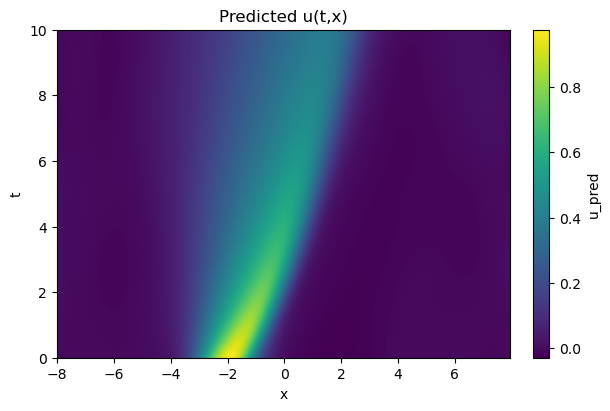

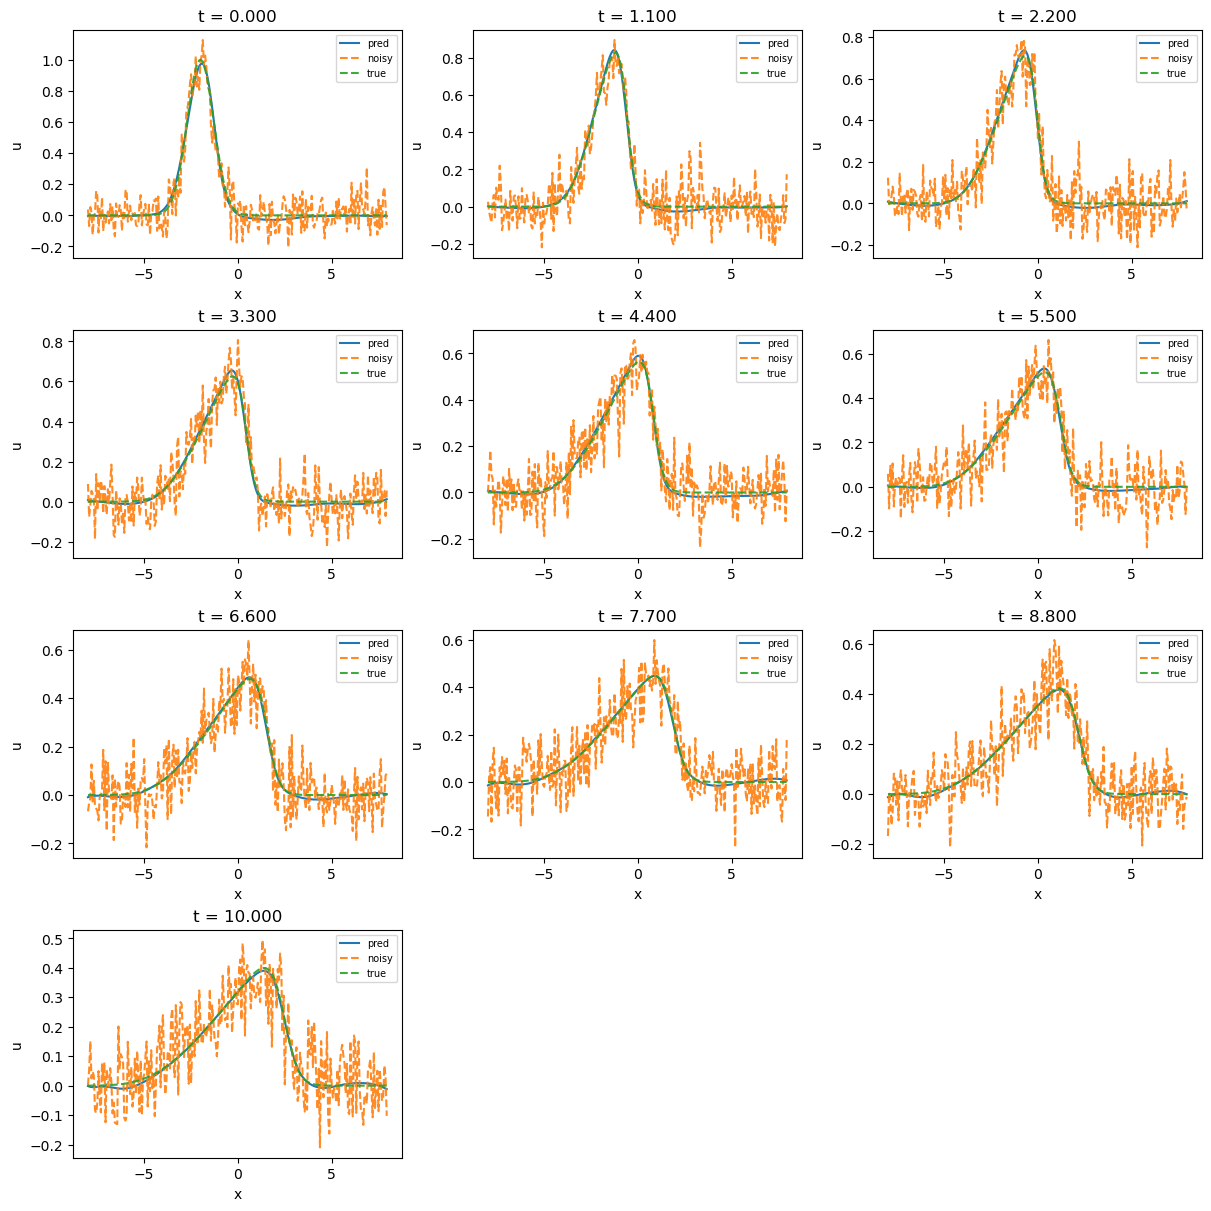

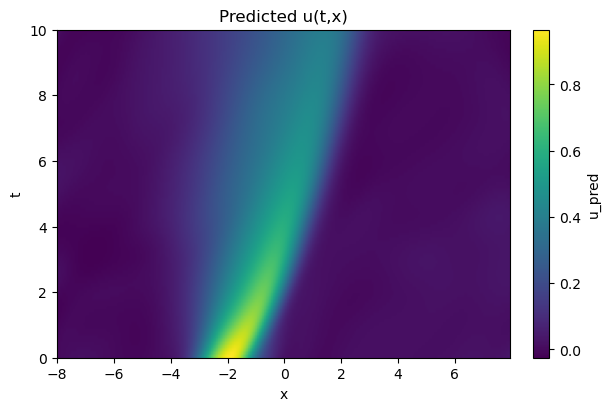

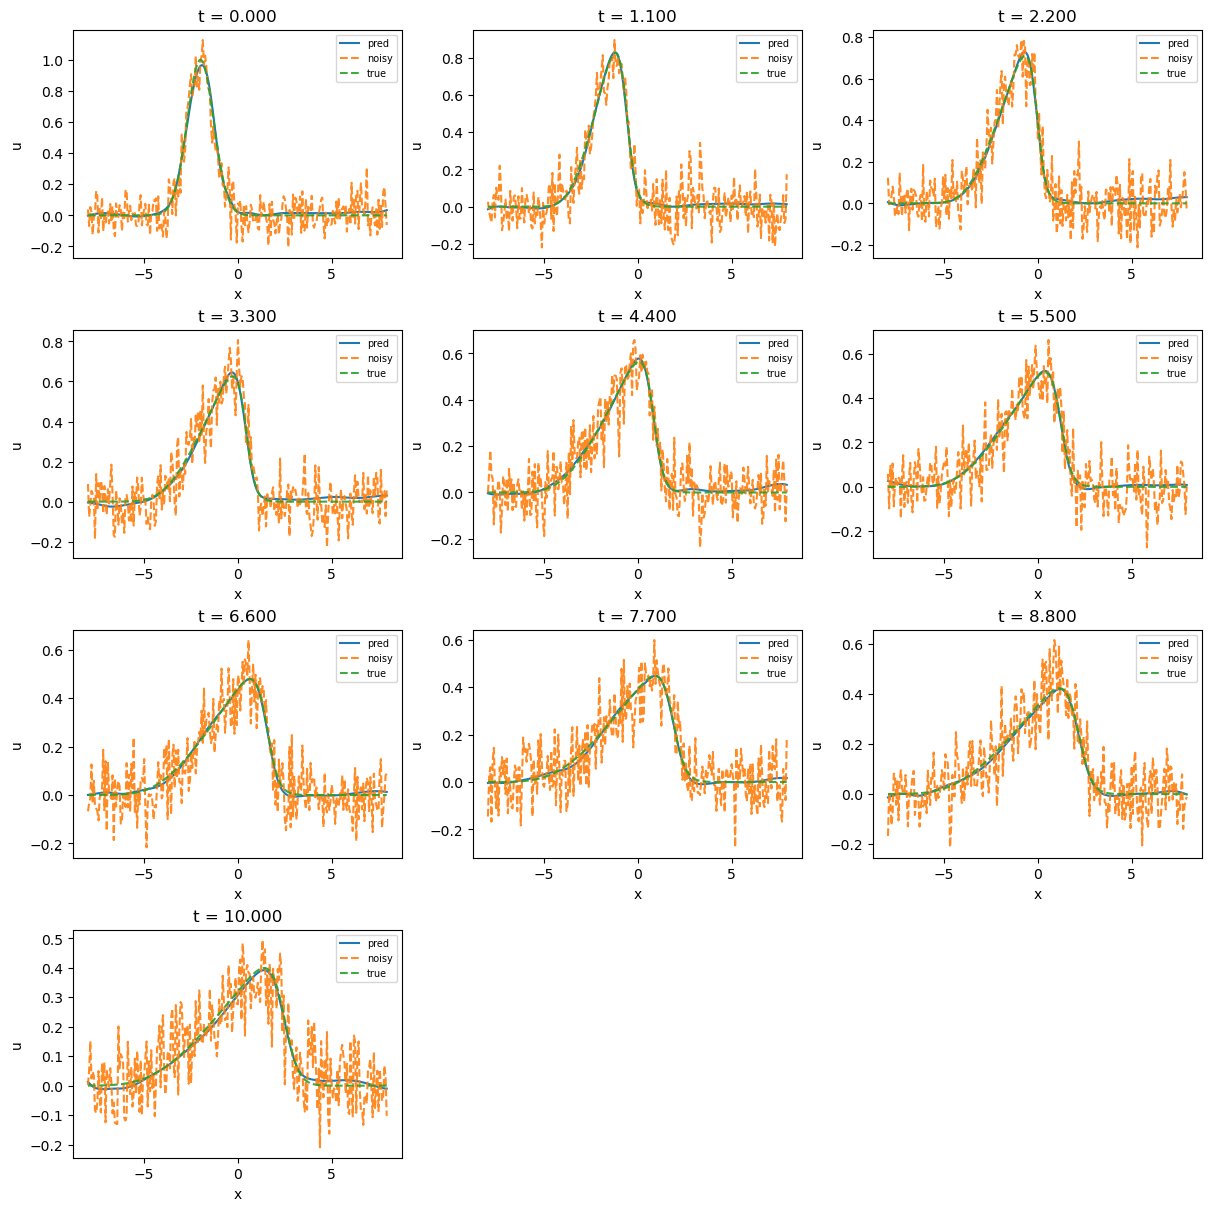

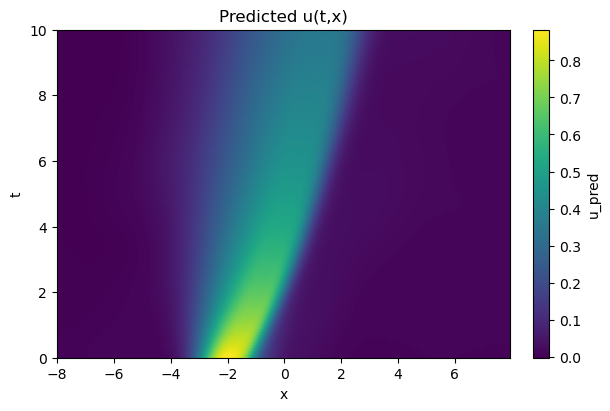

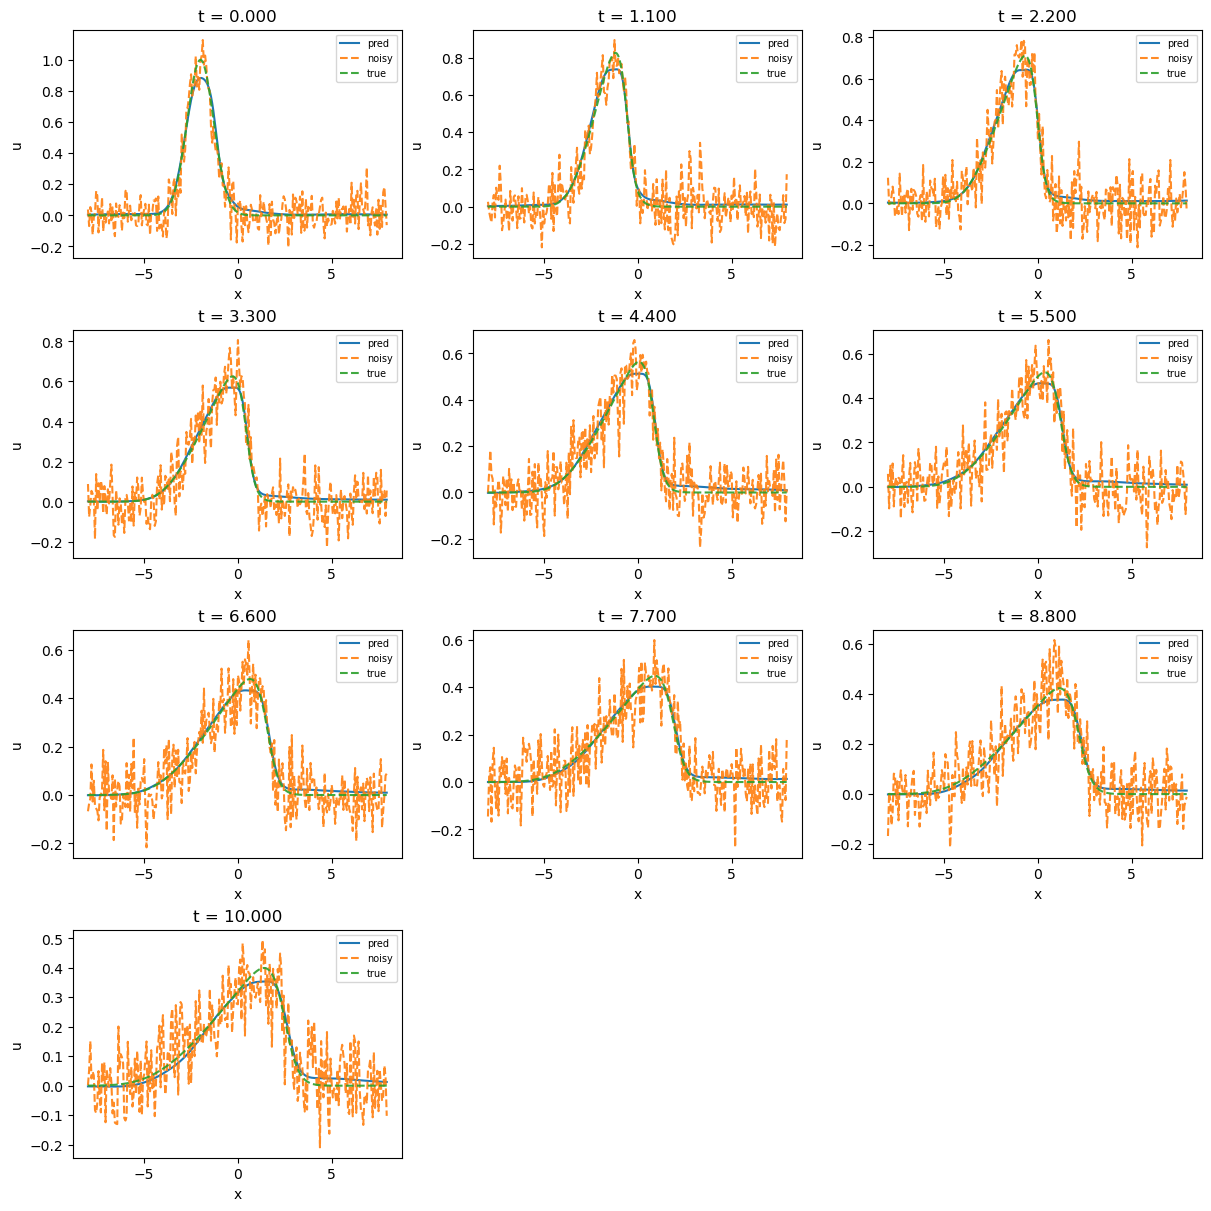

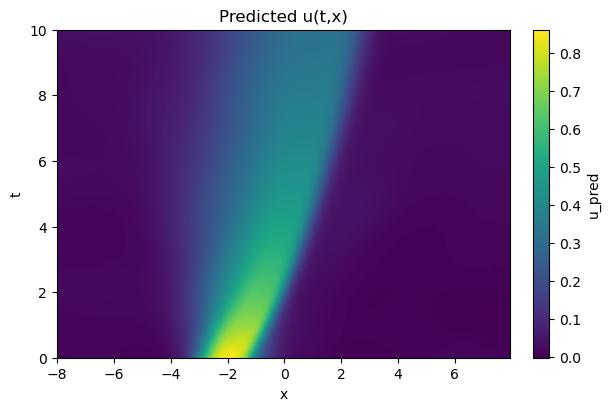

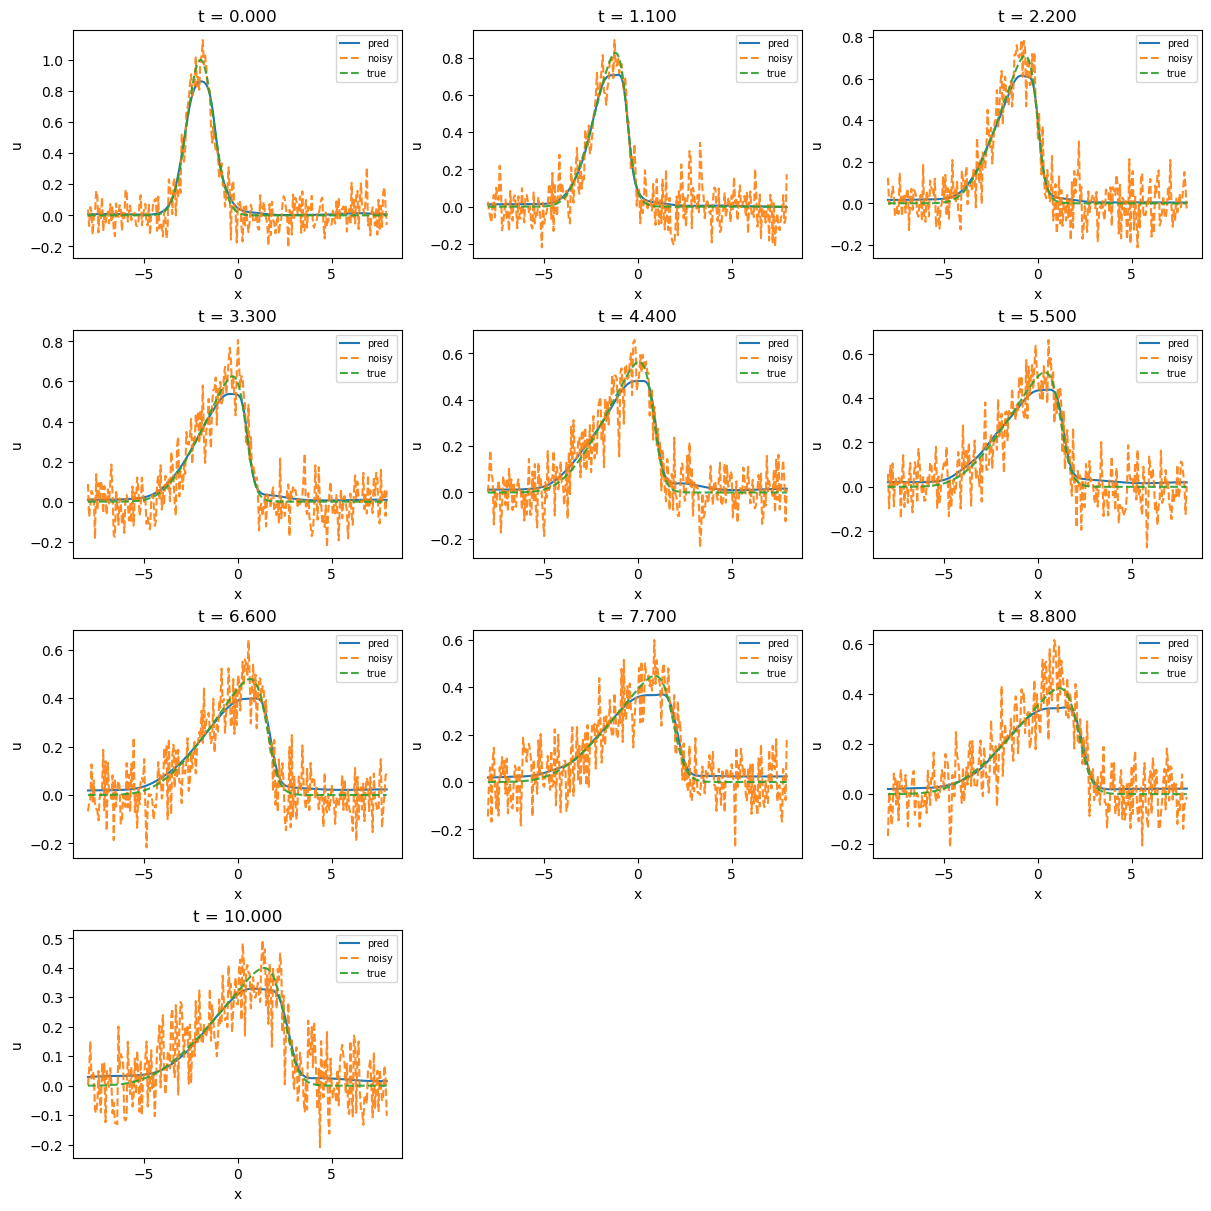

In [25]:
json_names = ["test1", "test2", "test3", "test4"]
for pde_mask_fn, tv_mask_fn, json_name in zip(pde_masks, tv_masks, json_names):
    print("\n \n \n \n* * * * * * * * * * * * * ")
    print(f"running models with {json_name} masking functions...")
    u_model, symnet = make_models()
    train = make_trainer(u_model, symnet, tv_mask_fn, pde_mask_fn)


    print('Starting training loop...')
    print(f'Initial lambda_tv: {train.lambda_tv.item()}, Initial lambda_pde: {train.lambda_pde.item():.4f}')
    print(f'step {0}:')

    lambda_tv_values = []
    lambda_pde_values = []

    train.lambda_pde.requires_grad_(True)
    train.lambda_tv.requires_grad_(True)
    # first, train to find best lambda values (using ADAM)
    for i in range(6000): 
        t,x,u_noisy,u_clean = hlprs.make_batch(batch_size=batch_size,
                                            t_torch=t_torch,
                                            x_torch=x_torch,
                                            y_clean=y_clean_torch,
                                            y_noisy=y_noisy_torch)
        out = train.step_adam(t=t,x=x,u_noisy=u_noisy,u_clean=u_clean, tv_fn=tv1d_space)
        lambda_tv_values.append(train.lambda_tv.item())
        lambda_pde_values.append(train.lambda_pde.item())

        if (i + 1)%log_every==0:
            print(f'step {i +1}:')
            print(f'loss {out["loss"]:.4f}')
            print(f'loss_tv_raw {out["loss_tv_raw"]:.4f}  | loss_pde_raw {out["loss_pde_raw"]:.4f}')
            print(f'loss_tv_masked" {out["mask_tv"]:}  | loss_pde_masked {out["mask_pde"]:.4f}')
            print(f'lambda_tv {train.lambda_tv.item()} | lambda_pde {train.lambda_pde.item():.4f}')
            model_loss = out["loss"]


    
    # now fix lambda values and train just the loss parameters (still using ADAM, since LBFGS is hard to implement)
    train.cfg.lr_tv = 0.0
    train.cfg.lr_pde = 0.0

    train.lambda_pde.requires_grad_(False)
    train.lambda_tv.requires_grad_(False)
    print('Starting second training loop with fixed lambda values...')
    out = None
    for i in range(6000):
        # apparently, lbfgs does better with full-batch training.
        t,x,u_noisy,u_clean = hlprs.make_batch(batch_size=1000,
                                            t_torch=t_torch,
                                            x_torch=x_torch,
                                            y_clean=y_clean_torch,
                                            y_noisy=y_noisy_torch)
        out = train.step_adam(t=t,x=x,u_noisy=u_noisy,u_clean=u_clean, tv_fn=tv1d_space)

        if (i + 1)%500==0:
            print(f'step {i +1}:')
            print(f'loss {out["loss"]:.4f}')
            print(f'loss_tv_raw {out["loss_tv_raw"]:.4f}  | loss_pde_raw {out["loss_pde_raw"]:.4f}')
            print(f'lambda_tv {train.lambda_tv.item()} | lambda_pde {train.lambda_pde.item():.4f}')
            print(f'lambda_tv_masked {out["mask_tv"]} | lambda_pde_masked {out["mask_pde"]:.4f}')

    hlprs.snapshot_comp(train.u, stride_x, stride_t, y_noisy_np, y_np, t_np, x_np, snap_no=10)[:0]

    hlprs.save_to_json(train, out, correct_coeffs, path=f"../ethan_work/mask_fns_runs/{json_name}.json")
        